# NDF & Forward Curve Analysis

This notebook uses `fxbt2.curves` to fetch, visualise, and analyse FX forward
curves across the full tenor spectrum (ON → 2Y).

### What you can do here

| Plot | Function | Question it answers |
|---|---|---|
| Today's curve | `plot_curve_today` | What does the curve look like right now? |
| Historical overlay | `plot_curve_history` | How has the curve shifted vs 1M/3M/1Y ago? |
| Percentile fan chart | `plot_percentile_bands` | Is today's curve cheap or rich vs history? |
| Implied yield structure | `plot_implied_yields` | What carry does each tenor imply? |
| Level heatmap | `plot_curve_heatmap` | How have levels evolved across tenors over time? |
| 4-panel dashboard | `plot_curve_dashboard` | All of the above at once |
| Tenor vs spot | `plot_tenor_vs_spot` | Is the forward premium widening or narrowing? |

### Data modes

**Live (Bloomberg Terminal):** Requires a running Terminal and `pdblp`.
All `fetch_*` methods on `CurveBuilder` connect live.

**Offline (pre-loaded data):** Feed a DataFrame of outright rates or forward
points into `CurveBuilder.from_dataframes()`. This notebook uses synthetic
data so you can run it without Bloomberg.

---


## 1 — Setup

In [1]:
import sys
sys.path.insert(0, "/Users/joshua.choy/Desktop/codebases/fx_projects/venv/lib/python3.11/site-packages")
sys.path.insert(1, "/Users/joshua.choy/Desktop/codebases/fx_projects")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

from fxbt2.curves import (
    CurveBuilder, TENORS, TENOR_DAYS, build_tenor_tickers,
    plot_curve_today, plot_curve_history, plot_percentile_bands,
    plot_implied_yields, plot_curve_heatmap, plot_curve_dashboard,
    plot_tenor_vs_spot,
)

print("Setup complete")
print(f"Available tenors: {TENORS}")

Setup complete
Available tenors: ['ON', '1W', '2W', '1M', '2M', '3M', '6M', '9M', '1Y', '2Y']


---
## 2 — Bloomberg Ticker Reference

`build_tenor_tickers()` returns the full set of Bloomberg tickers for any pair
across all tenors. Useful to verify what you'd be fetching before connecting.

**NDF pairs** (KRW, INR, BRL, TWD, PHP, IDR, COP, CLP, CNH) use outright tickers:
`{ROOT}+{TENOR} CMPT Curncy` e.g. `KWN+1M CMPT Curncy`

**Deliverable pairs** (EUR, GBP, JPY, AUD, etc.) use forward point tickers:
`{ROOT}{TENOR} CMPT Curncy` e.g. `EUR1M CMPT Curncy`


In [2]:
# Show the full ticker set for a selection of pairs
pairs_to_check = ["USDKRW", "USDINR", "USDBRL", "EURUSD", "USDJPY", "USDMXN"]

for pair in pairs_to_check:
    tickers = build_tenor_tickers(pair, fixing="CMPT")
    print(f"\n{pair}:")
    for tenor, ticker in tickers.items():
        print(f"  {tenor:4s}  {ticker}")


USDKRW:
  ON    KWN+ON CMPT Curncy
  1W    KWN+1W CMPT Curncy
  2W    KWN+2W CMPT Curncy
  1M    KWN+1M CMPT Curncy
  2M    KWN+2M CMPT Curncy
  3M    KWN+3M CMPT Curncy
  6M    KWN+6M CMPT Curncy
  9M    KWN+9M CMPT Curncy
  1Y    KWN+1Y CMPT Curncy
  2Y    KWN+2Y CMPT Curncy

USDINR:
  ON    IRN+ON CMPT Curncy
  1W    IRN+1W CMPT Curncy
  2W    IRN+2W CMPT Curncy
  1M    IRN+1M CMPT Curncy
  2M    IRN+2M CMPT Curncy
  3M    IRN+3M CMPT Curncy
  6M    IRN+6M CMPT Curncy
  9M    IRN+9M CMPT Curncy
  1Y    IRN+1Y CMPT Curncy
  2Y    IRN+2Y CMPT Curncy

USDBRL:
  ON    BCN+ON CMPT Curncy
  1W    BCN+1W CMPT Curncy
  2W    BCN+2W CMPT Curncy
  1M    BCN+1M CMPT Curncy
  2M    BCN+2M CMPT Curncy
  3M    BCN+3M CMPT Curncy
  6M    BCN+6M CMPT Curncy
  9M    BCN+9M CMPT Curncy
  1Y    BCN+1Y CMPT Curncy
  2Y    BCN+2Y CMPT Curncy

EURUSD:
  ON    EURON CMPT Curncy
  1W    EUR1W CMPT Curncy
  2W    EUR2W CMPT Curncy
  1M    EUR1M CMPT Curncy
  2M    EUR2M CMPT Curncy
  3M    EUR3M CMPT Curnc

---
## 3 — Synthetic Data

We generate 2 years of daily synthetic forward curve data for USDKRW (NDF)
and EURUSD (deliverable). The structure mimics what you'd get from Bloomberg:
a DataFrame with columns = tenors + 'spot', index = DatetimeIndex.

Replace this with real data via:
```python
cb = CurveBuilder(fixing='CMPT')
history = cb.fetch_history('USDKRW', con, start='20230101', end='20250101')
```


In [3]:
np.random.seed(42)
dates = pd.bdate_range("2023-01-02", "2024-12-31")
n = len(dates)

# ── USDKRW (NDF) ──────────────────────────────────────────────────────────────
# Spot: starts ~1320, slow drift upward
spot_krw = 1320 + np.cumsum(np.random.normal(0.05, 3.0, n))

# Forward curve: upward sloping (positive carry: KRW yields > USD)
# Outrights are ABOVE spot because USDKRW fwd pts are positive
TENOR_PREMIUM_KRW = {
    "ON": 0.3, "1W": 1.5, "2W": 3.0, "1M": 6.0,
    "2M": 12.0, "3M": 18.0, "6M": 36.0, "9M": 54.0, "1Y": 72.0, "2Y": 140.0,
}

krw_data = {"spot": spot_krw}
for tenor, base_premium in TENOR_PREMIUM_KRW.items():
    noise = np.random.normal(0, base_premium * 0.05, n)
    trend = np.cumsum(np.random.normal(0, 0.02, n))
    krw_data[tenor] = spot_krw + base_premium + noise + trend

history_krw = pd.DataFrame(krw_data, index=dates)
history_krw.index.name = "date"

# ── EURUSD (deliverable) ───────────────────────────────────────────────────────
# Spot: starts ~1.08
spot_eur = 1.0800 + np.cumsum(np.random.normal(0, 0.0040, n))

# EUR typically trades at a slight discount to USD (negative fwd pts → EUR outright < spot)
TENOR_DISCOUNT_EUR = {
    "ON": -0.000005, "1W": -0.000025, "2W": -0.000050, "1M": -0.000100,
    "2M": -0.000200, "3M": -0.000300, "6M": -0.000600, "9M": -0.000900,
    "1Y": -0.001200, "2Y": -0.002400,
}

eur_data = {"spot": spot_eur}
for tenor, base_discount in TENOR_DISCOUNT_EUR.items():
    noise = np.random.normal(0, abs(base_discount) * 0.05, n)
    eur_data[tenor] = spot_eur + base_discount + noise

history_eur = pd.DataFrame(eur_data, index=dates)
history_eur.index.name = "date"

print(f"USDKRW history: {history_krw.shape}  |  columns: {list(history_krw.columns)}")
print(f"EURUSD history: {history_eur.shape}  |  columns: {list(history_eur.columns)}")
print()
print("USDKRW last row (spot + outrights):")
print(history_krw.iloc[-1].round(2))

USDKRW history: (522, 11)  |  columns: ['spot', 'ON', '1W', '2W', '1M', '2M', '3M', '6M', '9M', '1Y', '2Y']
EURUSD history: (522, 11)  |  columns: ['spot', 'ON', '1W', '2W', '1M', '2M', '3M', '6M', '9M', '1Y', '2Y']

USDKRW last row (spot + outrights):
spot    1347.73
ON      1348.80
1W      1349.34
2W      1350.90
1M      1353.16
2M      1358.59
3M      1365.55
6M      1386.28
9M      1400.53
1Y      1422.19
2Y      1482.16
Name: 2024-12-31 00:00:00, dtype: float64


---
## 4 — Today's Forward Curve

The simplest view: what does the curve look like at the latest date?

- **Upward sloping** = positive carry (forward > spot) → shorting base earns carry
- **Downward sloping** = negative carry (forward < spot) → selling the pair earns carry
- **Kinks** in the curve can signal liquidity stress or upcoming events at a specific tenor


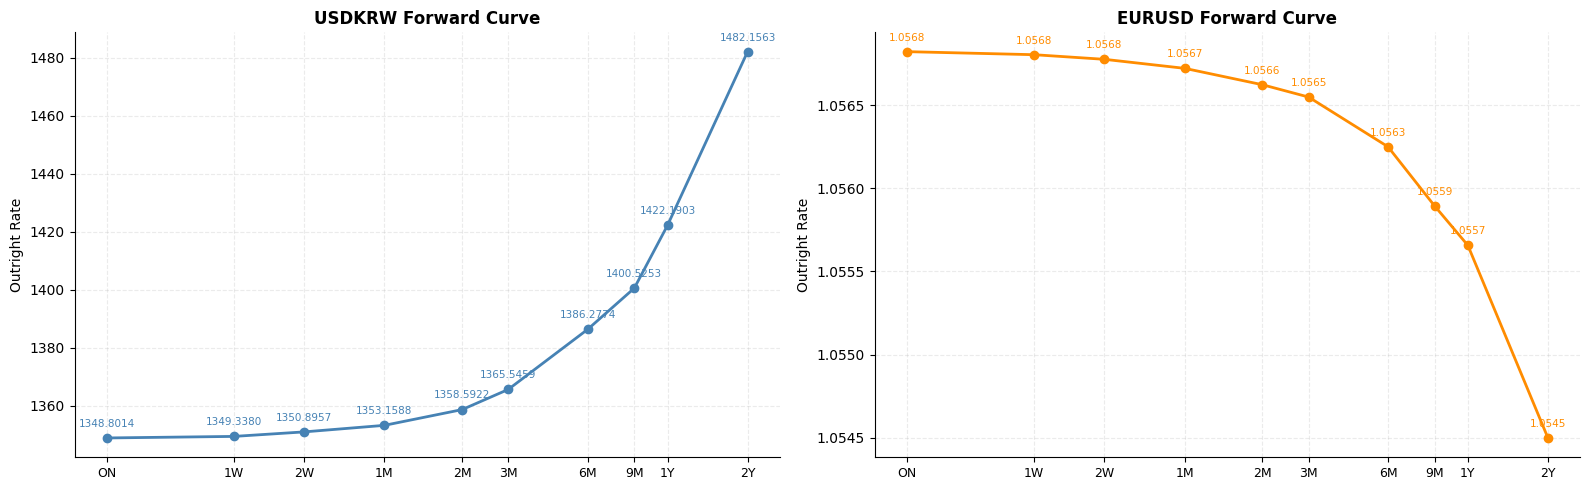

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# USDKRW (NDF) — today's snapshot
today_krw = history_krw.iloc[-1].drop("spot")
plot_curve_today(today_krw, pair="USDKRW", ax=axes[0])

# EURUSD (deliverable) — today's snapshot
today_eur = history_eur.iloc[-1].drop("spot")
plot_curve_today(today_eur, pair="EURUSD", ax=axes[1], color="darkorange")

plt.tight_layout()
plt.show()

**Reading the curve:**

For USDKRW (NDF): each outright is the agreed exchange rate for settling at that tenor.
The 1M outright being above spot means: if you agree today to buy USD/sell KRW in 1 month,
you'll pay more KRW per USD than the current spot rate. This reflects the KRW interest rate
being higher than USD — the market is pricing in that carry.

For EURUSD: the slight downward slope means the EUR forward discount (EUR yields < USD yields).


---
## 5 — Historical Curve Overlay

Compare today's curve to where it was 1M, 3M, 6M, and 1Y ago.

**What shifts in the curve mean:**
- **Parallel shift up/down** = overall spot move
- **Steepening** = carry is increasing (rate differential widening)
- **Flattening** = carry is compressing (rate differential narrowing)
- **Inversion** = near-term funding stress (short-end premium > long-end)


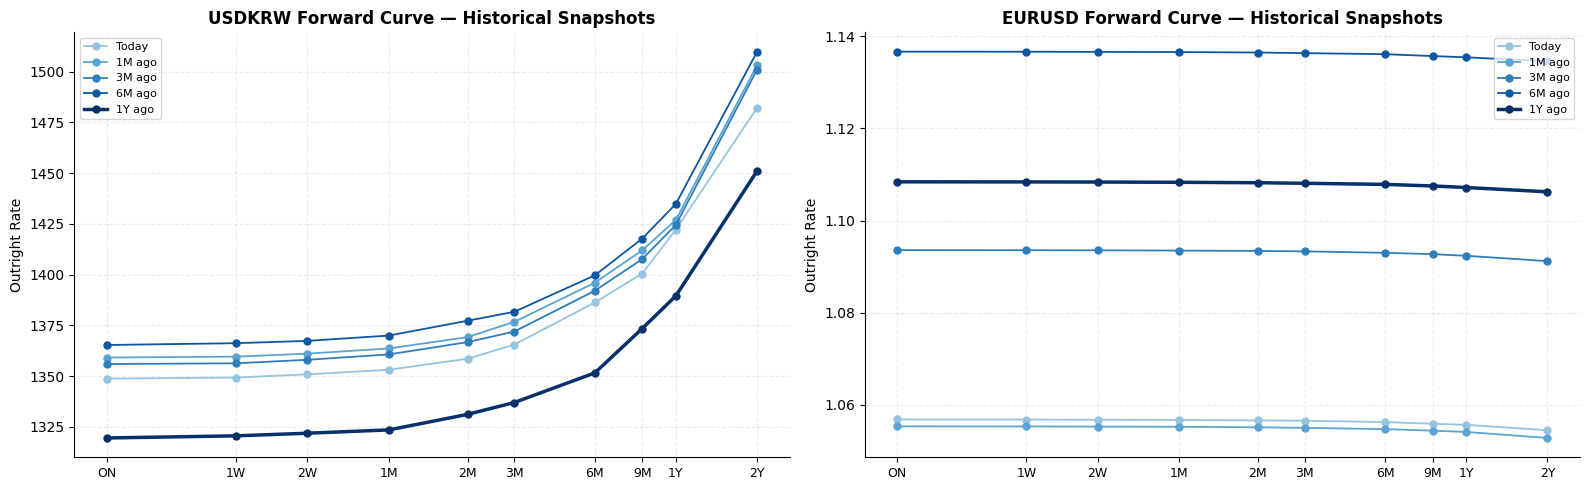

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_curve_history(history_krw, pair="USDKRW", ax=axes[0])
plot_curve_history(history_eur, pair="EURUSD", ax=axes[1])
plt.tight_layout()
plt.show()

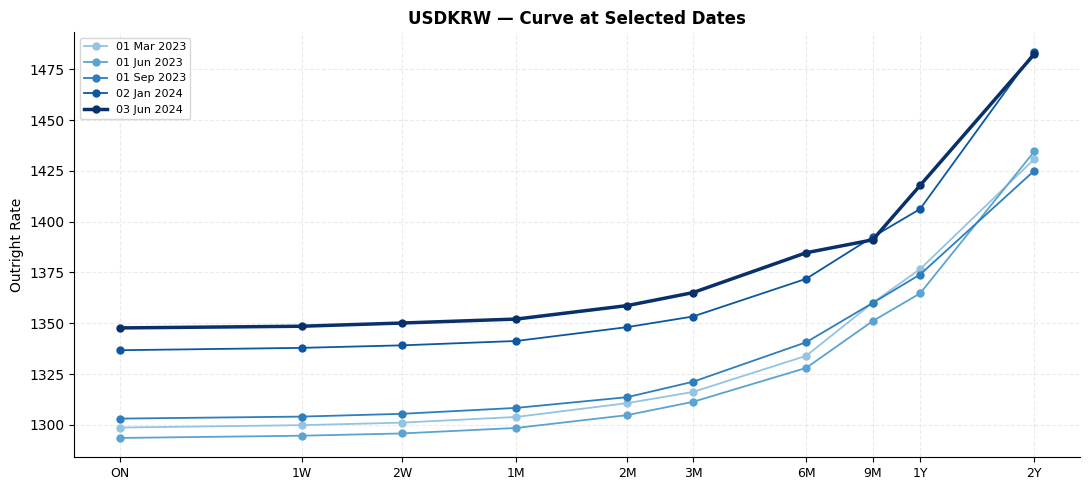

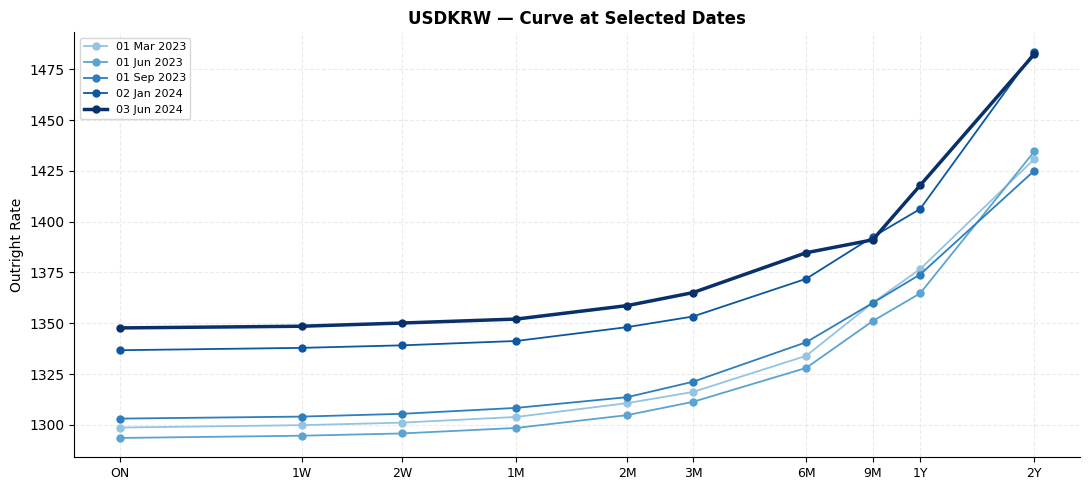

In [6]:
# Custom snapshot dates: compare specific dates of interest
# e.g. before/after a central bank meeting or market event
custom_dates = ["2023-03-01", "2023-06-01", "2023-09-01", "2024-01-02", "2024-06-03"]

plot_curve_history(
    history_krw,
    pair="USDKRW",
    snapshot_dates=custom_dates,
    title="USDKRW — Curve at Selected Dates",
)

---
## 6 — Percentile Fan Chart: Cheap or Rich vs History?

This is the most important chart for **trade formulation**.

The shaded bands show the 10th–90th and 25th–75th percentile range of
historical outright rates. Today's curve (red) is overlaid.

**How to use this:**
- **Red line above the 90th pct band**: outrights are historically elevated → forward is expensive relative to history
- **Red line below the 10th pct band**: outrights are at historically low levels → forward is cheap
- **Red line inside the 25–75 band**: levels are in the middle of the historical range — no strong directional signal from valuation alone

You can also pass `hist_window=252` to use only the last 1 year of history as the reference period.


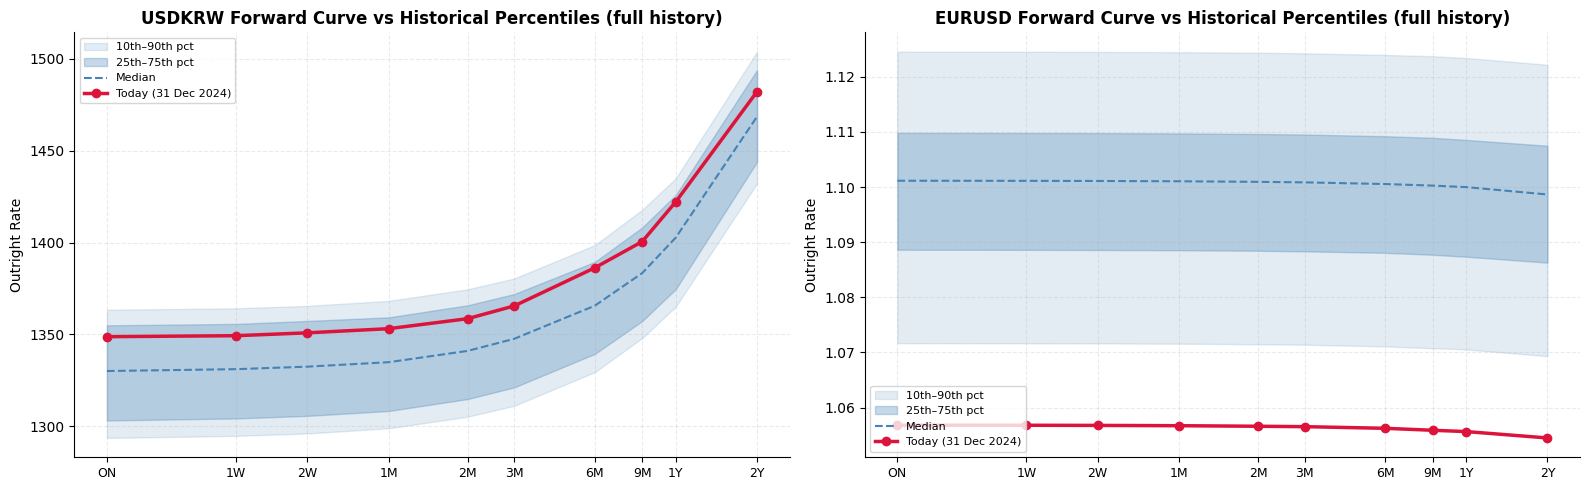

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_percentile_bands(history_krw, pair="USDKRW", ax=axes[0])
plot_percentile_bands(history_eur, pair="EURUSD", ax=axes[1])
plt.tight_layout()
plt.show()

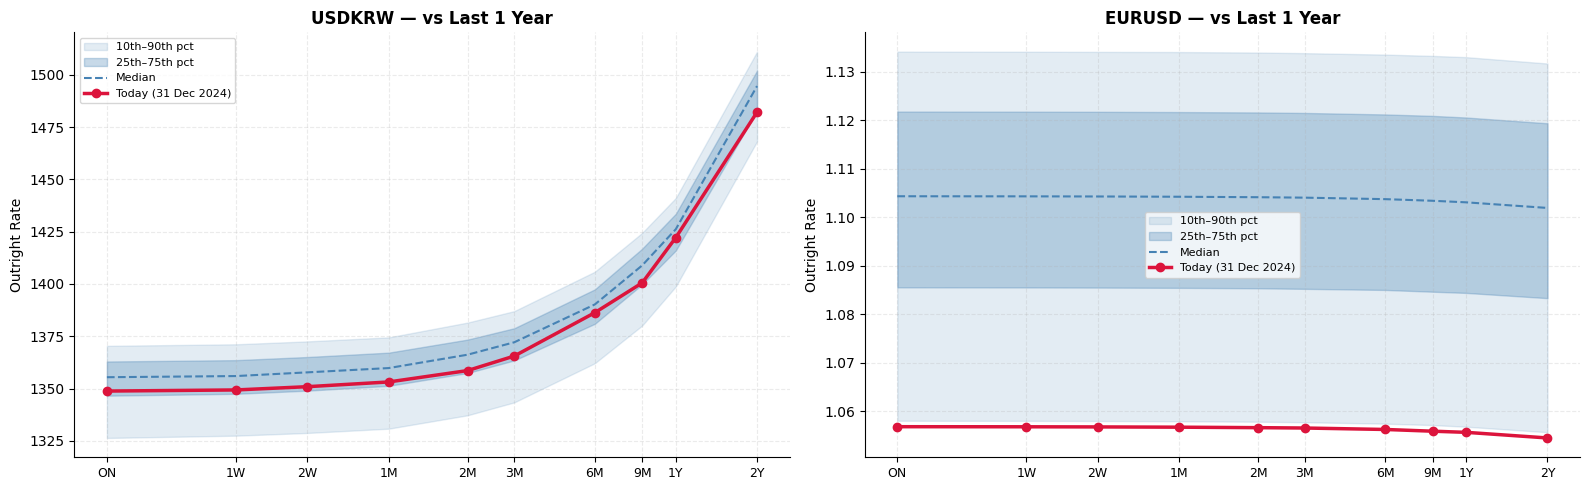

In [8]:
# Rolling 1-year window: how does today compare to just the last year?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_percentile_bands(history_krw, pair="USDKRW", ax=axes[0], hist_window=252,
                      title="USDKRW — vs Last 1 Year")
plot_percentile_bands(history_eur, pair="EURUSD", ax=axes[1], hist_window=252,
                      title="EURUSD — vs Last 1 Year")
plt.tight_layout()
plt.show()

---
## 7 — Implied Yield Term Structure

Converts outright rates into **annualised implied yields** at each tenor:

```
implied_yield(tenor) = (outright / spot − 1) × (252 / tenor_days)
```

This tells you the annualised return from the forward premium or discount.

**What to look for:**
- **Upward sloping yield curve**: longer tenors imply higher carry → typical in EM
- **Inverted yield curve**: short end yields > long end → near-term rate pressure or funding stress
- **Shift in the curve over time**: central bank policy changes show up here before they appear in spot


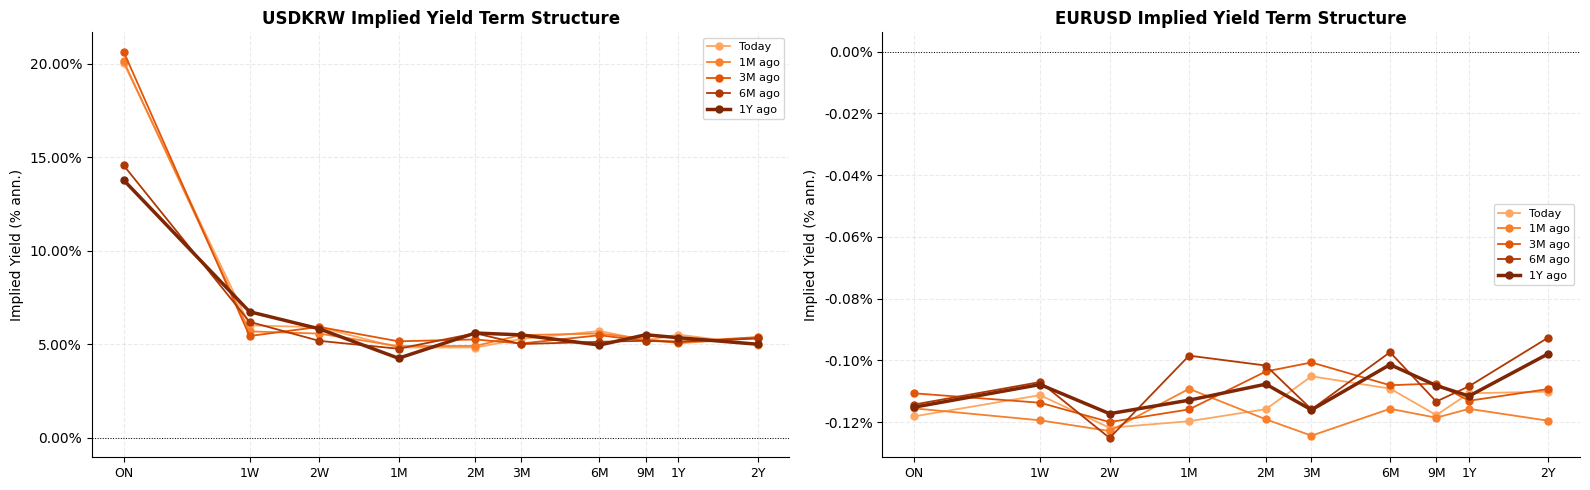

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_implied_yields(history_krw, pair="USDKRW", ax=axes[0])
plot_implied_yields(history_eur, pair="EURUSD", ax=axes[1])
plt.tight_layout()
plt.show()

In [10]:
# Compute the implied yield history as a DataFrame for further analysis
cb = CurveBuilder()
yield_krw = cb.implied_yield_curve(history_krw)
print("USDKRW implied yields (annualised %) — last 5 rows:")
(yield_krw * 100).round(3).tail()

USDKRW implied yields (annualised %) — last 5 rows:


,ON,1W,2W,1M,2M,3M,6M,9M,1Y,2Y
date,,,,,,,,,,
2024-12-25,20.764,5.462,6.278,4.634,5.300,5.115,5.429,5.456,5.737,5.205
2024-12-26,20.032,5.905,5.943,4.543,5.236,5.580,5.458,5.528,5.274,4.764
2024-12-27,19.728,5.543,5.818,4.403,5.015,5.398,4.516,5.705,5.315,5.059
2024-12-30,20.508,5.830,5.946,4.640,5.035,5.173,5.620,4.976,5.390,5.586
2024-12-31,20.064,6.020,5.922,4.835,4.837,5.288,5.721,5.223,5.525,4.987


---
## 8 — Level Heatmap

Shows outright levels across all tenors over the full history.
- X-axis = time
- Y-axis = tenor (ON at bottom, 2Y at top)
- Colour = outright rate (green = low, red = high)

**What to look for:**
- Consistent colour gradient from bottom to top = stable, normally-sloped curve
- Sudden colour breaks = repricing event (rate move, policy change)
- Horizontal banding at a specific tenor = that tenor is trading differently from the rest


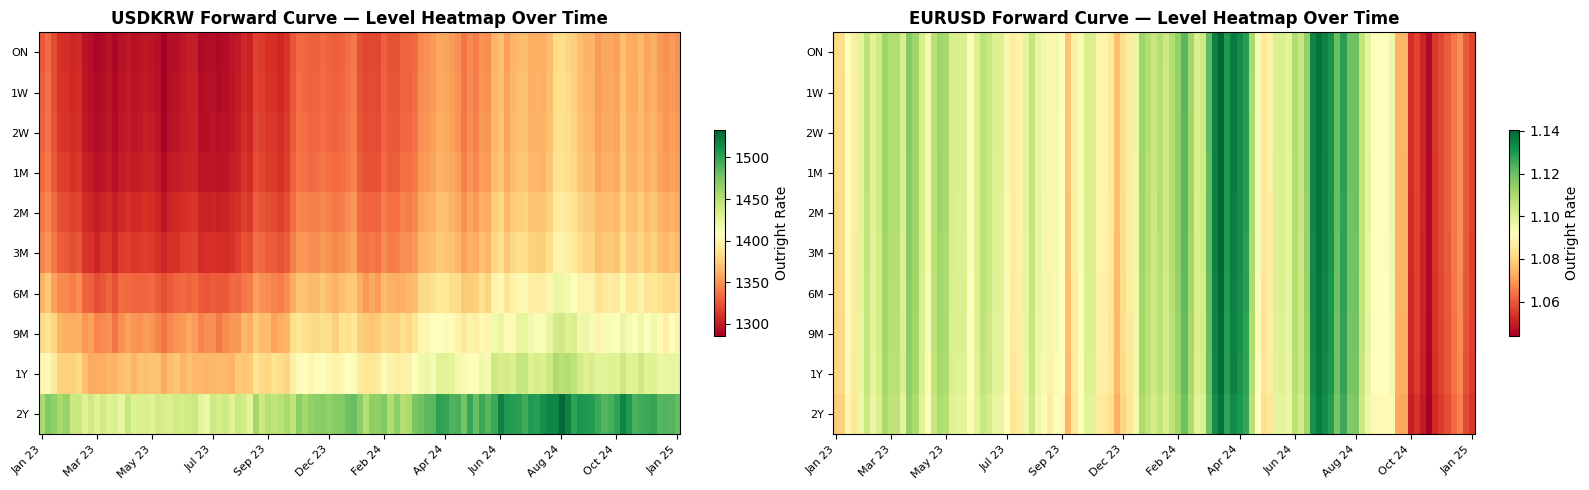

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_curve_heatmap(history_krw, pair="USDKRW", ax=axes[0])
plot_curve_heatmap(history_eur, pair="EURUSD", ax=axes[1])
plt.tight_layout()
plt.show()

---
## 9 — Single Tenor vs Spot

Track how a specific tenor's outright compares to spot over time.

The **bottom panel** shows the forward premium/discount:
- Positive (blue) = outright > spot → pair is in forward premium → positive carry for the seller
- Negative (red) = outright < spot → pair is in forward discount → negative carry for the seller

A widening premium signals **increasing carry** — this is often a leading indicator
of one-sided positioning and eventual mean-reversion.


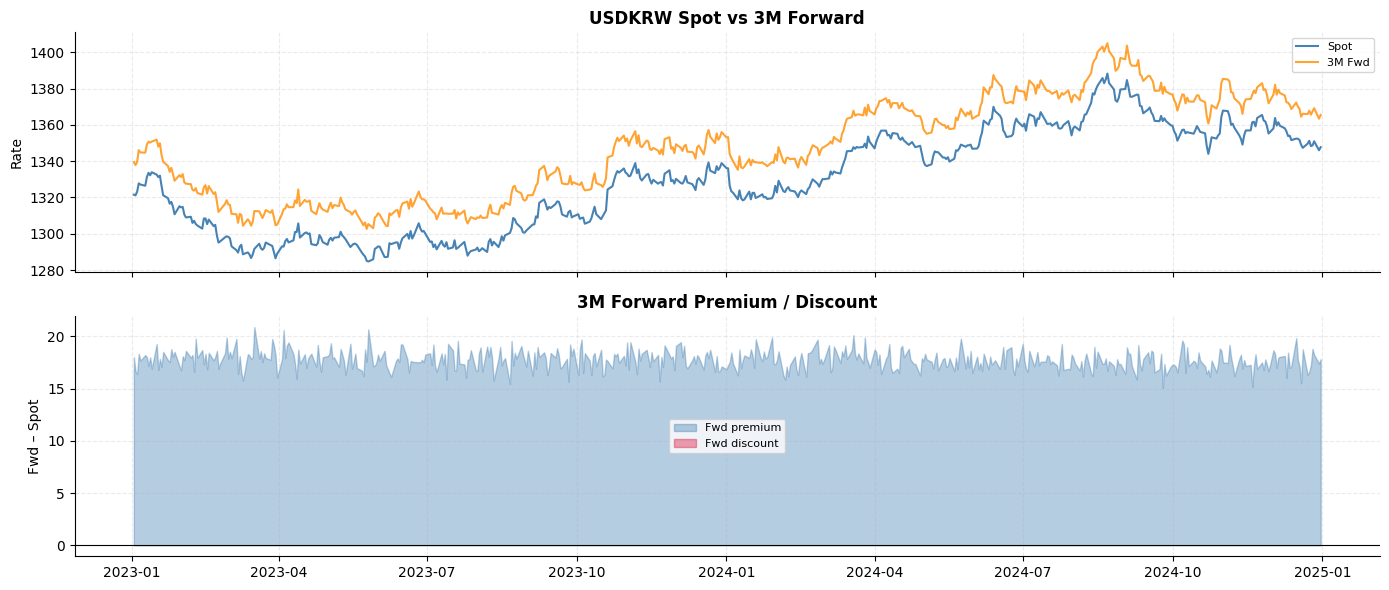

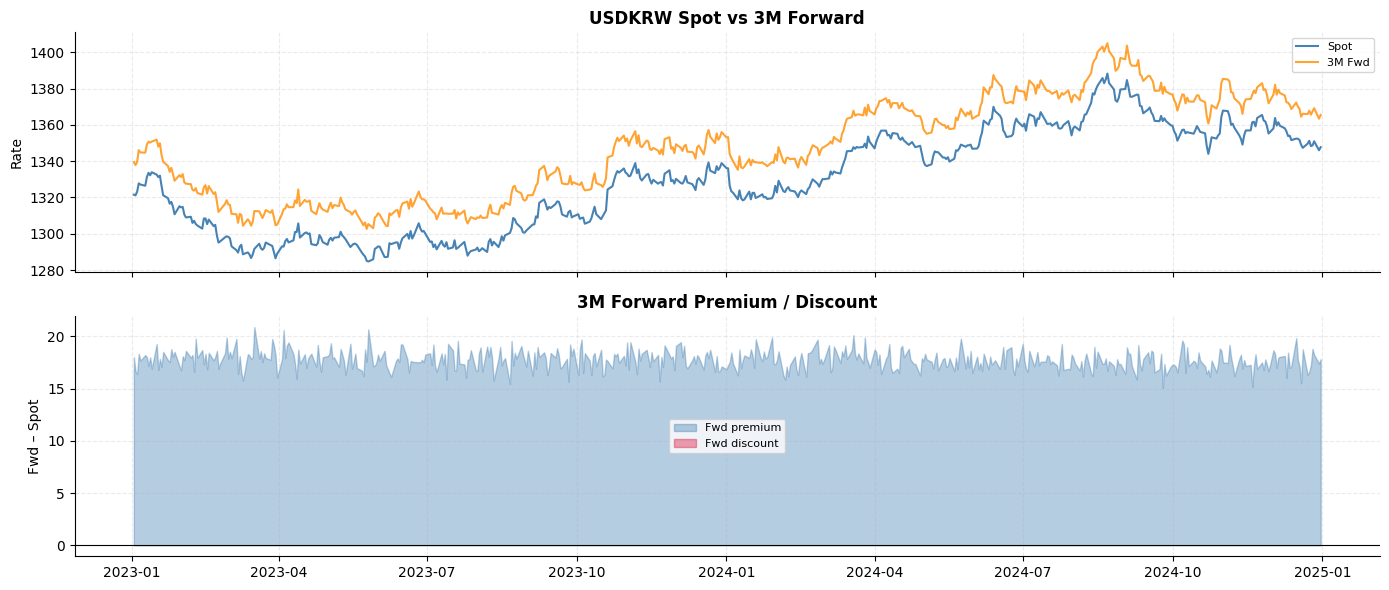

In [12]:
# Track the 3M outright vs spot for USDKRW
plot_tenor_vs_spot(history_krw, pair="USDKRW", tenor="3M")

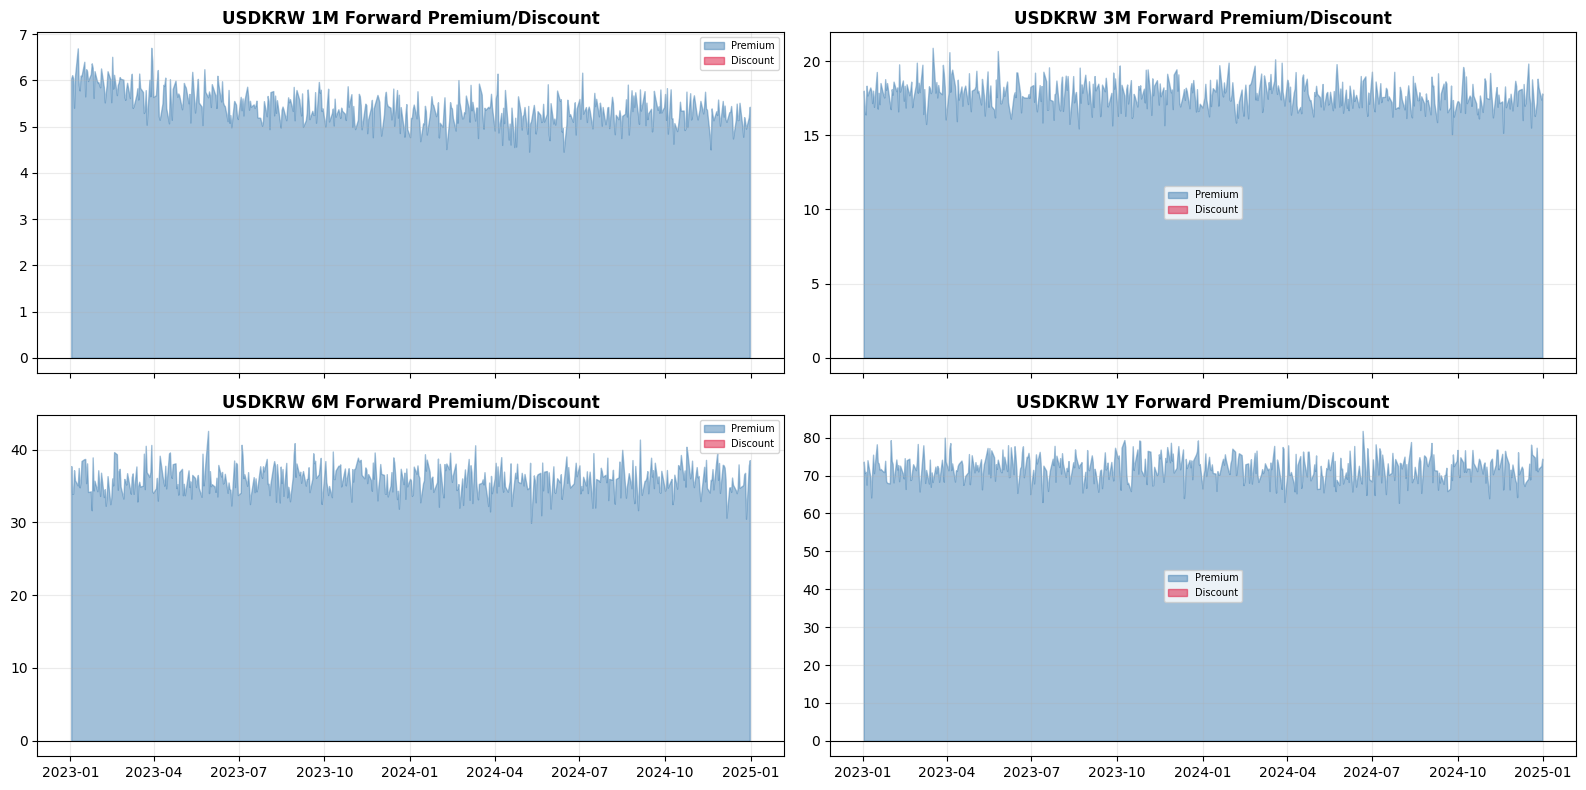

In [13]:
# Compare premium/discount across multiple tenors
tenors_to_check = ["1M", "3M", "6M", "1Y"]

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for i, tenor in enumerate(tenors_to_check):
    spread = history_krw[tenor] - history_krw["spot"]
    axes[i].fill_between(spread.index, spread.values, 0,
                         where=spread >= 0, color="steelblue", alpha=0.5, label="Premium")
    axes[i].fill_between(spread.index, spread.values, 0,
                         where=spread < 0, color="crimson", alpha=0.5, label="Discount")
    axes[i].axhline(0, color="black", lw=0.8)
    axes[i].set_title(f"USDKRW {tenor} Forward Premium/Discount", fontweight="bold")
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

---
## 10 — 4-Panel Dashboard

All four views on a single figure. Use this as your daily curve monitor.


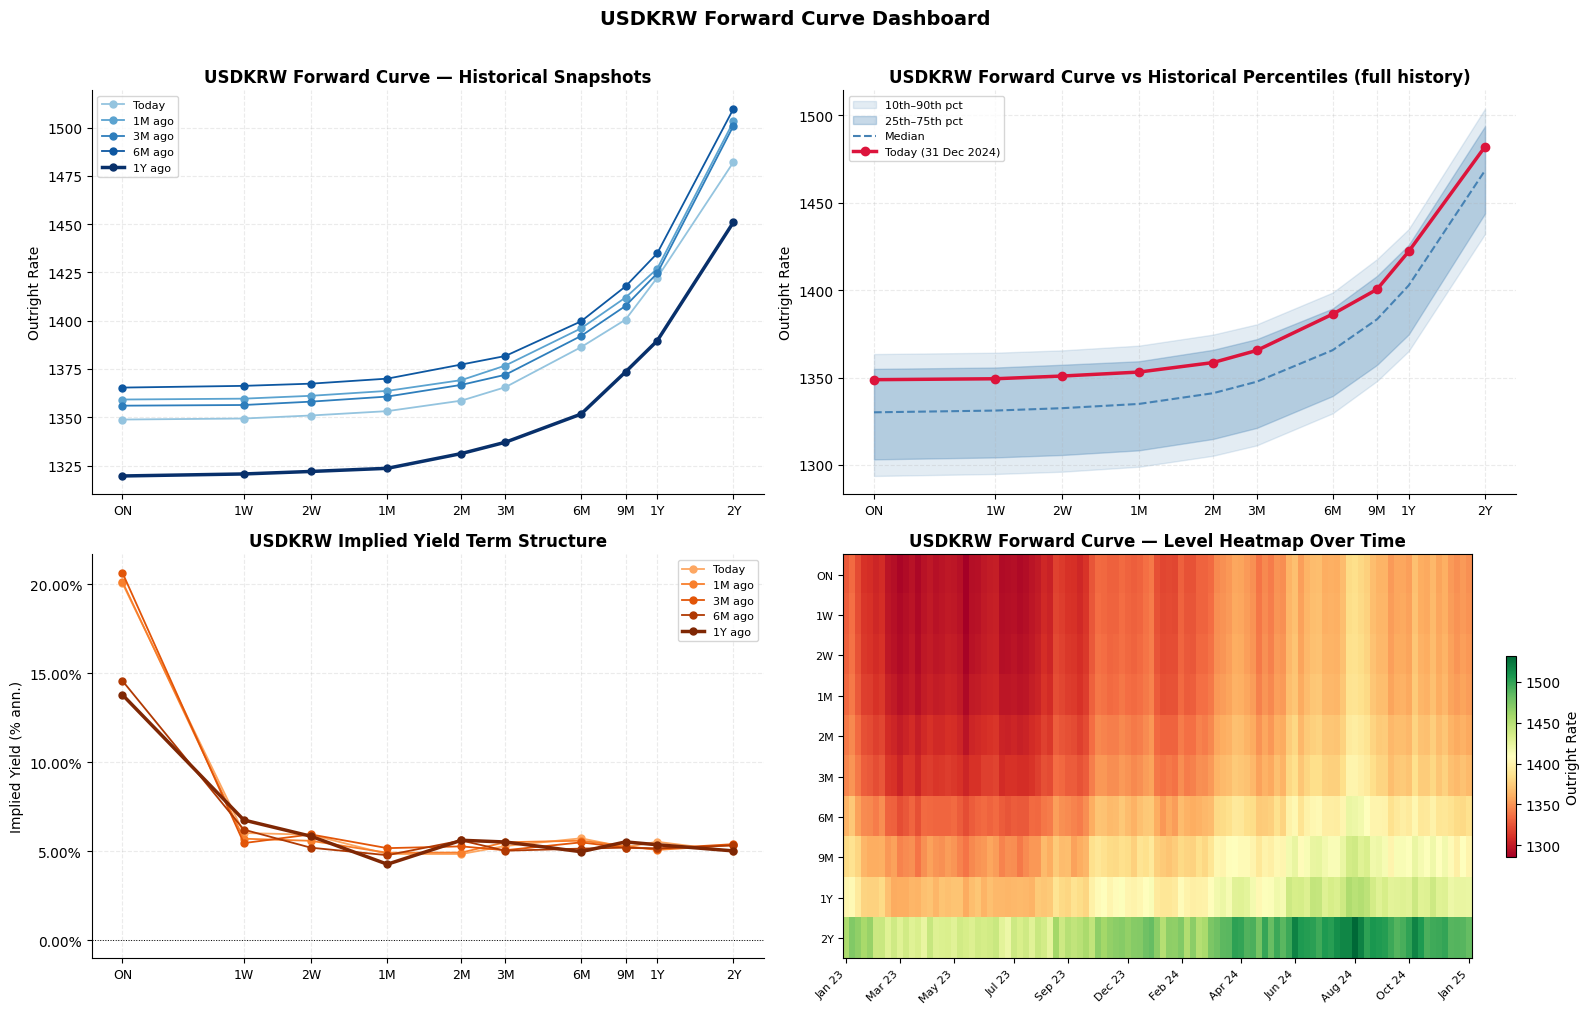

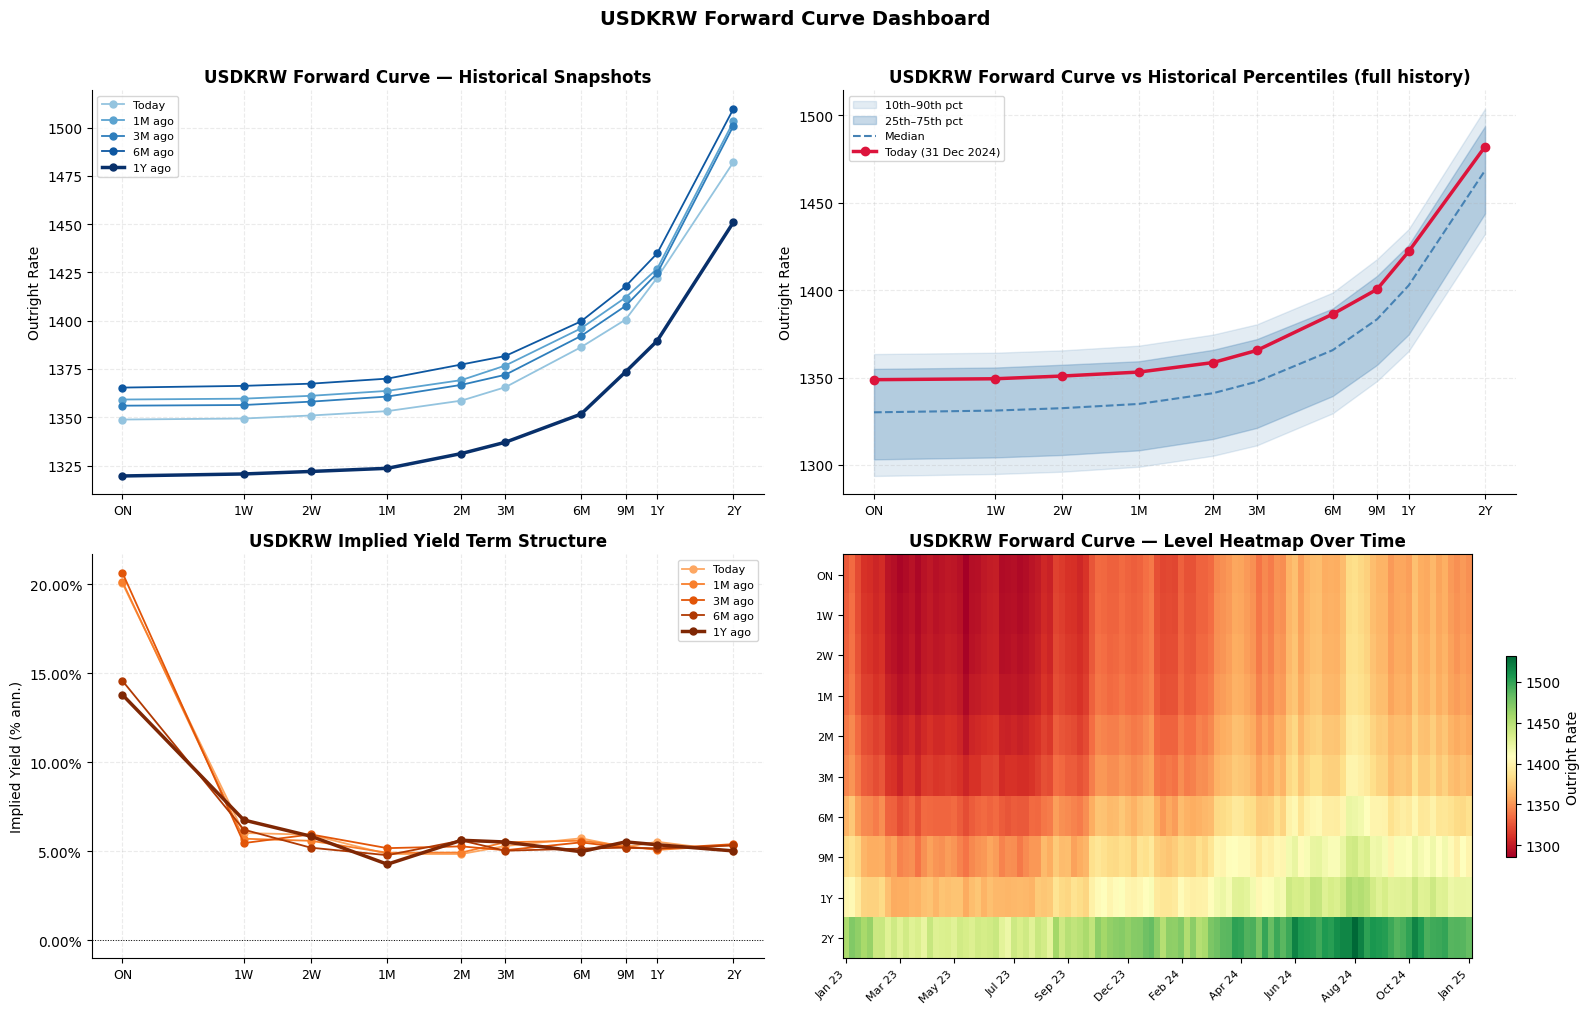

In [14]:
plot_curve_dashboard(history_krw, pair="USDKRW")

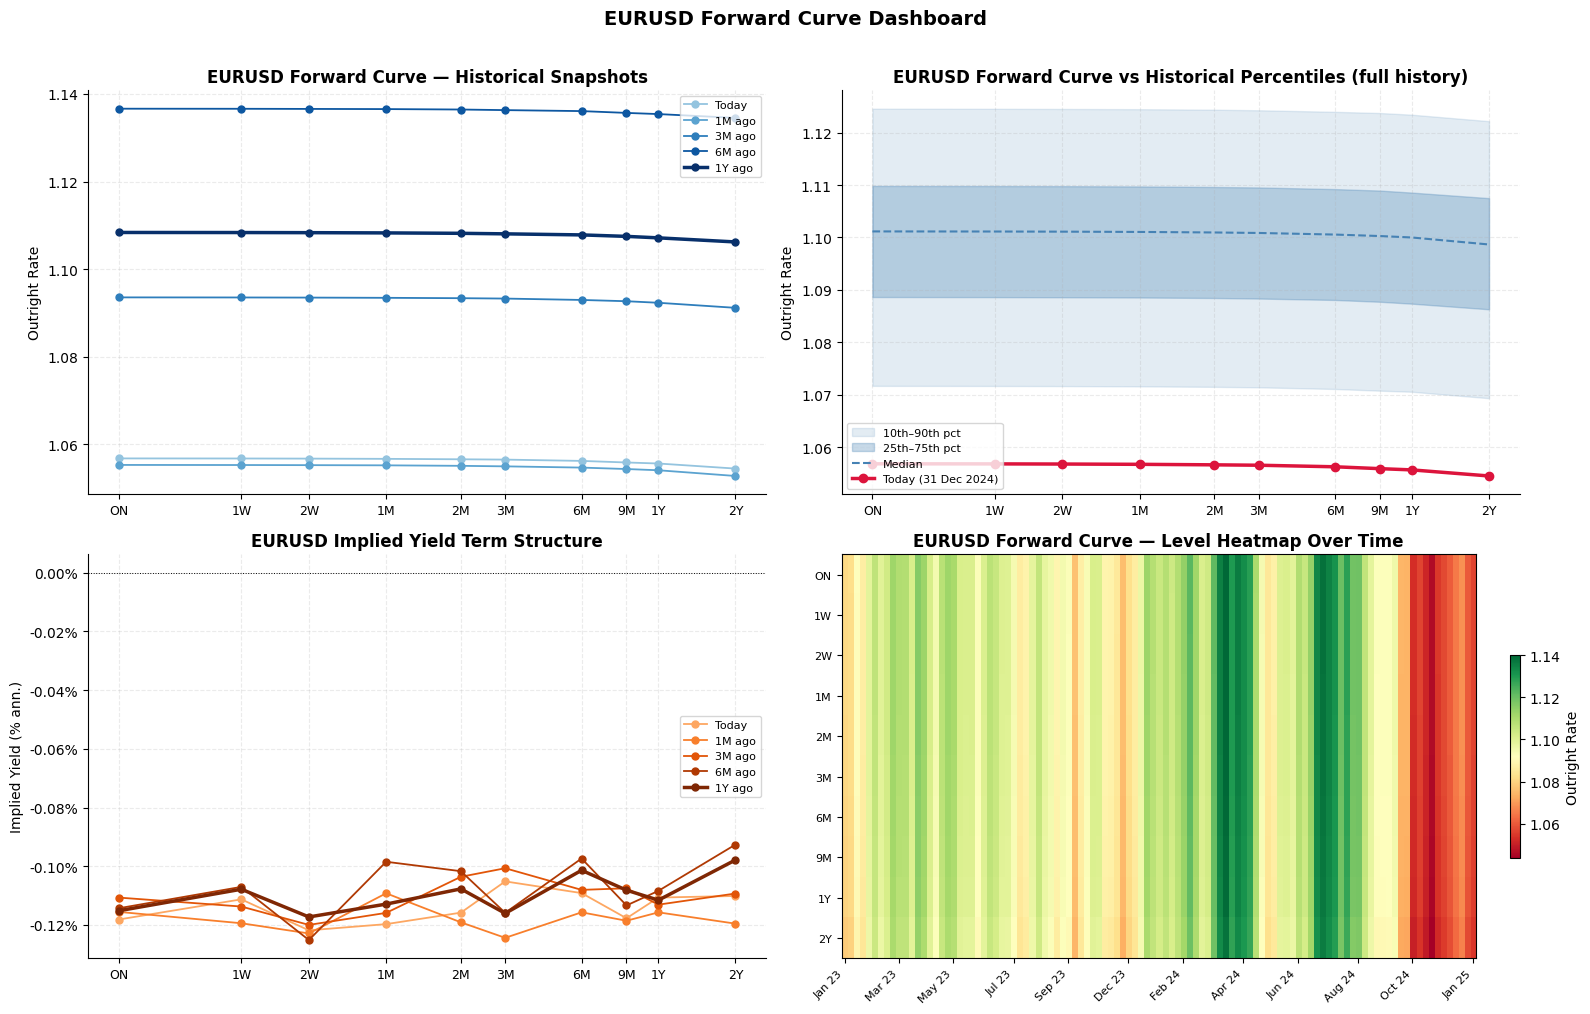

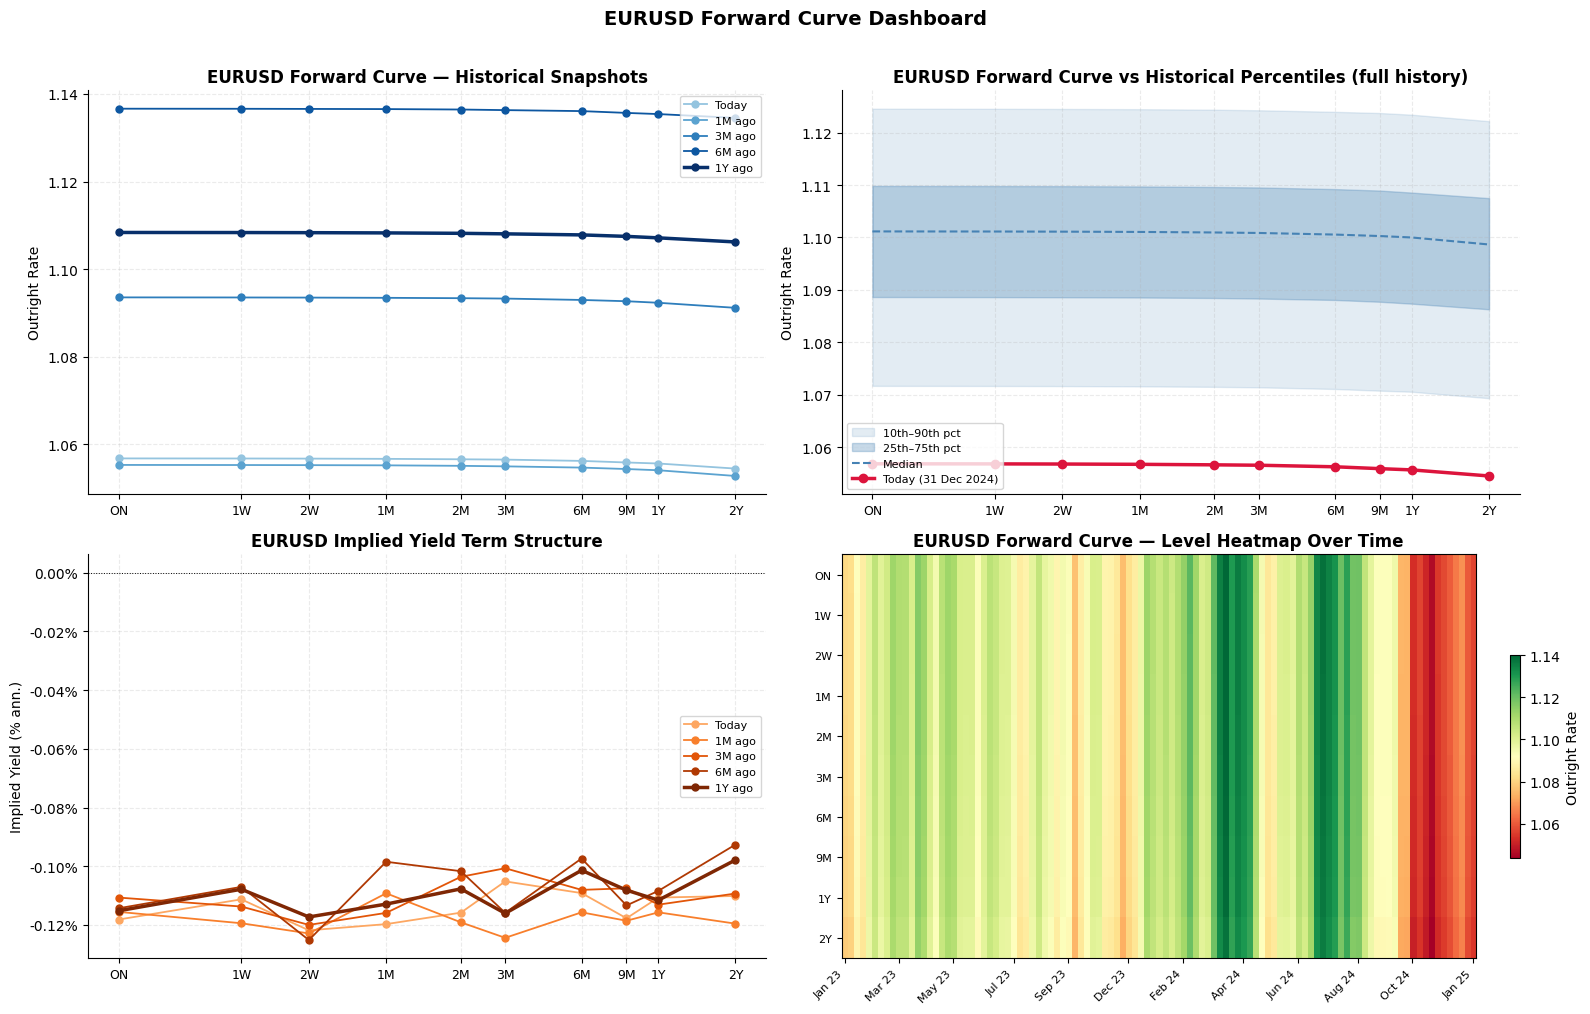

In [15]:
plot_curve_dashboard(history_eur, pair="EURUSD")

---
## 11 — Comparing Implied Yields Across Pairs

Compare the 1M implied yield across multiple pairs to identify relative carry.

This is a quick screen for **which pairs have the most carry** right now and
whether current levels are elevated or compressed vs history.


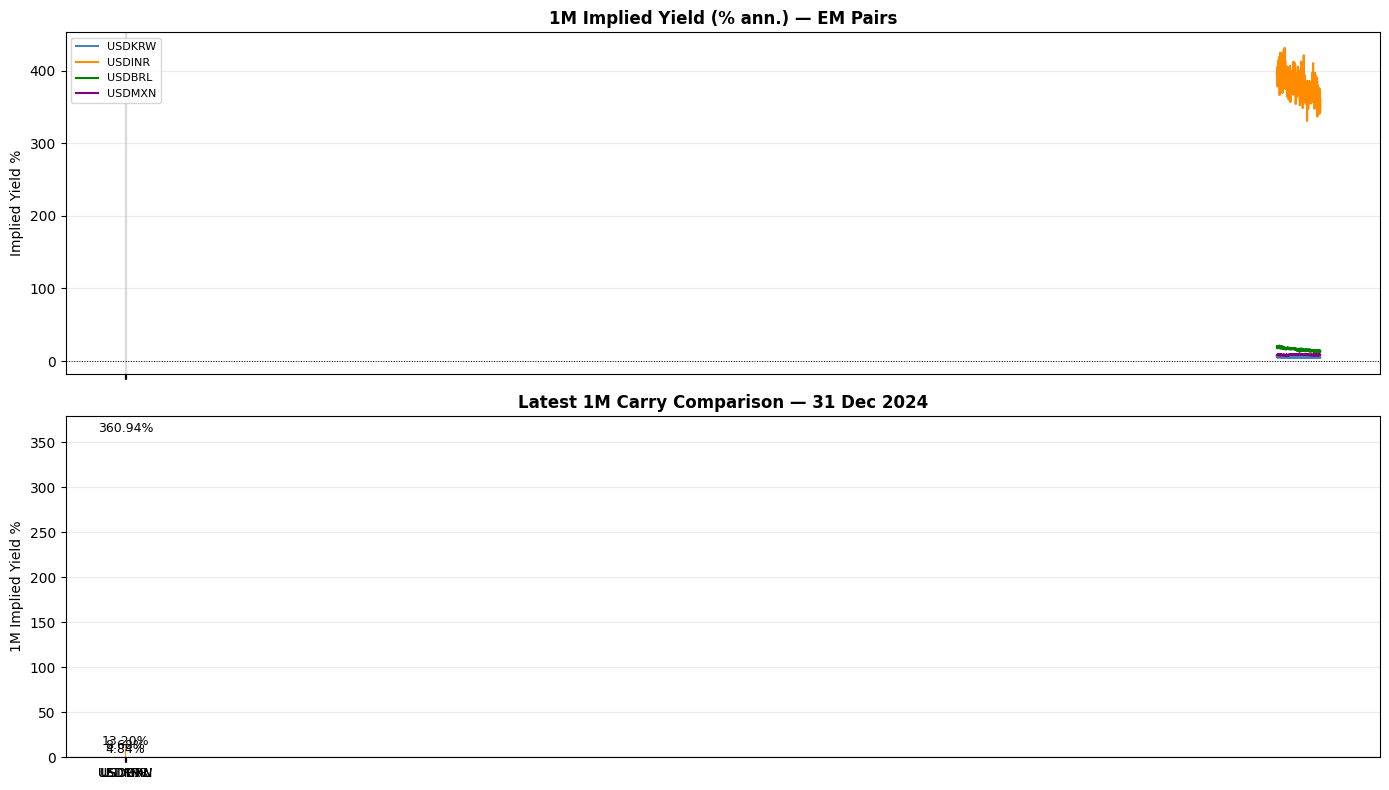

In [16]:
# Build synthetic data for a few EM NDF pairs
np.random.seed(99)
n = len(dates)

pairs_data = {}

# USDKRW (already built)
pairs_data["USDKRW"] = history_krw

# USDINR: spot ~84, moderate carry
spot_inr = 84.0 + np.cumsum(np.random.normal(0.01, 0.15, n))
inr_data = {"spot": spot_inr}
for tenor, premium in {"1M": 28, "3M": 85, "6M": 170, "1Y": 340}.items():
    inr_data[tenor] = spot_inr + premium + np.random.normal(0, premium * 0.03, n)
pairs_data["USDINR"] = pd.DataFrame(inr_data, index=dates)

# USDBRL: spot ~5.0, high carry
spot_brl = 5.00 + np.cumsum(np.random.normal(0.001, 0.03, n))
brl_data = {"spot": spot_brl}
for tenor, premium in {"1M": 0.08, "3M": 0.24, "6M": 0.48, "1Y": 0.95}.items():
    brl_data[tenor] = spot_brl + premium + np.random.normal(0, premium * 0.04, n)
pairs_data["USDBRL"] = pd.DataFrame(brl_data, index=dates)

# USDMXN: spot ~17.5, moderate-high carry
spot_mxn = 17.5 + np.cumsum(np.random.normal(0.002, 0.08, n))
mxn_data = {"spot": spot_mxn}
for tenor, premium in {"1M": 0.12, "3M": 0.36, "6M": 0.72, "1Y": 1.44}.items():
    mxn_data[tenor] = spot_mxn + premium + np.random.normal(0, premium * 0.04, n)
pairs_data["USDMXN"] = pd.DataFrame(mxn_data, index=dates)

# Compute 1M implied yield for each pair
cb = CurveBuilder()
yield_1m = {}
for pair, hist in pairs_data.items():
    if "1M" in hist.columns and "spot" in hist.columns:
        yld = cb.implied_yield_curve(hist, tenors=["1M"])
        yield_1m[pair] = yld["1M"] * 100  # convert to %

yield_df = pd.DataFrame(yield_1m).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Time series of 1M implied yields
for pair, col in [("USDKRW","steelblue"),("USDINR","darkorange"),
                  ("USDBRL","green"),("USDMXN","purple")]:
    axes[0].plot(yield_df.index, yield_df[pair], lw=1.5, label=pair, color=col)
axes[0].axhline(0, color="black", lw=0.7, linestyle=":")
axes[0].set_title("1M Implied Yield (% ann.) — EM Pairs", fontweight="bold")
axes[0].set_ylabel("Implied Yield %")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25)

# Latest cross-sectional bar chart
latest = yield_df.iloc[-1].sort_values(ascending=False)
axes[1].bar(range(len(latest)), latest.values, color=["steelblue","darkorange","green","purple"])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title(f"Latest 1M Carry Comparison — {yield_df.index[-1].strftime('%d %b %Y')}",
                  fontweight="bold")
axes[1].set_ylabel("1M Implied Yield %")
axes[1].set_xticks(range(len(latest)))
axes[1].set_xticklabels(latest.index.tolist(), fontsize=9)
axes[1].grid(True, alpha=0.25, axis="y")
for i, (pair, v) in enumerate(latest.items()):
    axes[1].text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

---
## 12 — Live Bloomberg Usage

When you have a Bloomberg Terminal running, replace the synthetic data with live fetches.

```python
import pdblp

# Connect to Bloomberg Terminal
con = pdblp.BCon(debug=False, port=8194, timeout=50000)
con.start()

cb = CurveBuilder(fixing='CMPT')

# Fetch today's curve
curve_today = cb.fetch_curve('USDKRW', con)
plot_curve_today(curve_today, pair='USDKRW')

# Fetch 2-year history
history = cb.fetch_history('USDKRW', con, start='20230101', end='20250101')
plot_curve_dashboard(history, pair='USDKRW')

# Close connection when done
con.stop()
```

### Available tickers per pair

Use `build_tenor_tickers()` to inspect what Bloomberg tickers will be fetched:

```python
from fxbt2.curves import build_tenor_tickers
tickers = build_tenor_tickers('USDKRW', fixing='CMPT')
# {'ON': 'KWN+ON CMPT Curncy', '1W': 'KWN+1W CMPT Curncy', ...}
```

### Supported pairs

Any pair where the non-USD currency is in the ticker dictionary:
`EUR, GBP, JPY, AUD, NZD, CAD, CHF, NOK, SEK, HUF, CZK, PLN, ILS`
`MXN, ZAR, BRL, CLP, COP, KRW, INR, IDR, TWD, PHP, CNH, SGD, THB`

NDF pairs (KRW, INR, IDR, TWD, PHP, BRL, CLP, COP, CNH) fetch outright tickers directly.
All others fetch forward points and construct outrights from spot.
